# Generating Time-correleted Distribution

### Q1
Generating Time-Correlated Gaussian Distribution

(a) Generate a set of 1000 random numbers drawn from a Gaussian distribution with zero
mean and unit variance.

(b) Using this initial set, generate consecutive sets of 1000 numbers each, ensuring that each
new set is correlated with the previous one. The correlation should decay exponentially
with a characteristic correlation time τc.

(c) Compute and plot the autocorrelation function across different sets to verify the expo-
nential decay.

In [122]:
#imports
import numpy as np
import matplotlib.pyplot as plt

#PART A

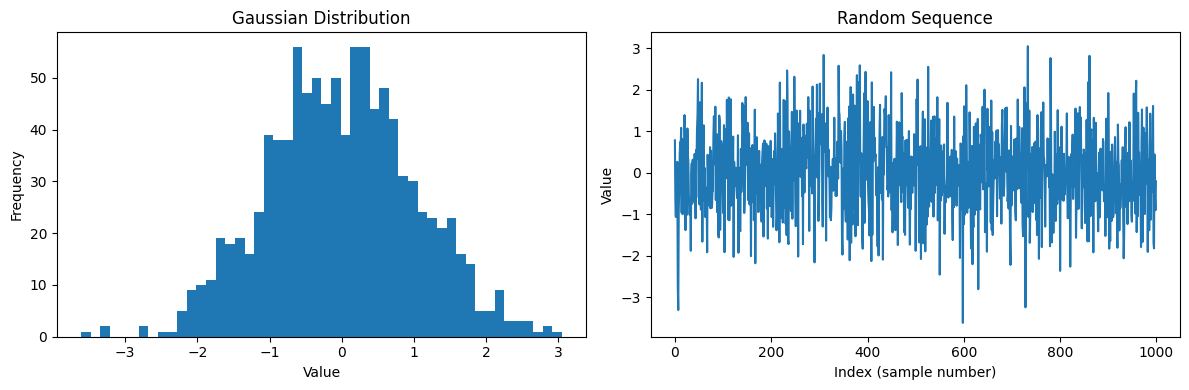

In [123]:
#Generating a set of 1000 random numbers drawn from a Gaussian distribution with zero mean and unit variance
x = np.random.normal(0, 1, 1000)

#plot histogram
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(x, bins=50)
axes[0].set_title("Gaussian Distribution")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")

#Time series plot
axes[1].plot(x)
axes[1].set_title("Random Sequence")
axes[1].set_xlabel("Index (sample number)")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

# PART B

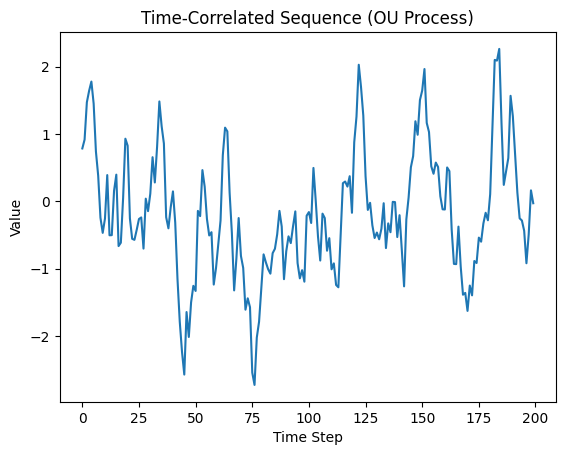

In [127]:
initial_set  = x
def Generating_sets(initial_set, N, T, tau, dt=1):
    time_steps = int(T / dt)
    VX = np.zeros((time_steps, N))
    VX[0] = initial_set

    for t in range(1, time_steps):
        dW = np.random.normal(0, np.sqrt(dt), N)
        VX[t] = VX[t-1] - (VX[t-1] / tau) * dt + np.sqrt(2 / tau) * dW

    return VX

#parameters
N = 1000
T = 20
tau = 1
dt = 0.1
VX = Generating_sets(initial_set, N, T, tau, dt)

#plot
plt.plot(VX[:,0])
plt.title("Time-Correlated Sequence (OU Process)")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.show()

# PART C

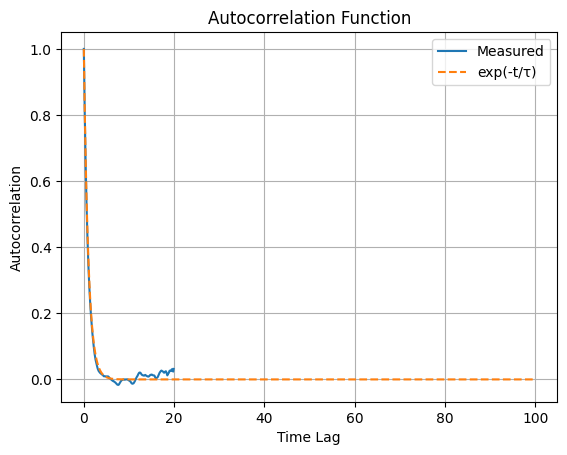

In [129]:
def autocorrelation_ou(VX, max_lag_steps):
    X_mean = np.mean(VX, axis=1, keepdims=True)
    X_fluct = VX - X_mean
    denom = np.mean(X_fluct**2)

    AC = np.array([
        np.mean(X_fluct[:-t] * X_fluct[t:]) if t > 0 else denom
        for t in range(max_lag_steps)
    ])

    return AC / denom

#parameters
max_lag_time = 1
max_lag_steps = int(max_lag_time / dt)
time_lags = np.arange(max_lag_steps) * dt

AC_vec = autocorrelation_ou(VX, max_lag_steps)
theory_AC = np.exp(-time_lags / tau)

#plot autocorrelation
plt.plot(time_lags, AC_vec, label="Measured")
plt.plot(time_lags, theory_AC, '--', label="exp(-t/τ)")
plt.xlabel("Time Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function")
plt.legend()
plt.grid()
plt.show()
